# Семестровая работа по дисциплине «Искусственный интеллект»

**Тема:** Физически информированные нейронные сети (PINN): оценка стоимости европейского опциона на базе уравнения Блэка-Шоулза.



## 1. Введение

### 1.1. Актуальность темы
В современной финансовой инженерии точная и оперативная оценка стоимости производных финансовых инструментов (опционов) является критически важной задачей для управления рисками крупнейших институциональных инвесторов.

Историческим стандартом в этой области выступает математическая модель Блэка-Шоулза, представляющая собой дифференциальное уравнение в частных производных (PDE). Традиционные подходы к его решению опираются на численные методы: конечно-разностные схемы (построение сеток) или симуляции методом Монте-Карло.

**Проблема существующих подходов:** При увеличении количества рыночных факторов и усложнении параметров контракта классические численные алгоритмы сталкиваются с высокой вычислительной ресурсоемкостью («проклятием размерности»), что ограничивает их применение в системах высокочастотной торговли реального времени.

### 1.2. Цель работы
Целью данной работы является исследование и реализация методов искусственного интеллекта — а именно **Физически информированных нейронных сетей (Physics-Informed Neural Networks, PINN)** — для ускорения и оптимизации процесса расчета стоимости европейских опционов.

**Суть предлагаемого подхода:** Вместо стандартного обучения нейросети исключительно на исторических данных, фундаментальный экономический закон (уравнение Блэка-Шоулза) интегрируется непосредственно в функцию потерь (Loss function) модели. Данный подход позволяет нейросети осуществлять поиск решений, строго соответствующих теоретическим законам финансового рынка, обеспечивая при этом многократное преимущество в скорости вычислений по сравнению с сеточными методами.

## 2. Теоретическая база исследования

### 2.1. Экономическое содержание опциона
**Опцион типа Call (колл)** представляет собой контракт, предоставляющий право (но не обязанность) приобрести базовый актив (например, акцию) по заранее зафиксированной цене $K$ (страйк-цена) в определенный момент времени в будущем $T$ (момент экспирации).

В процессе моделирования ключевыми переменными выступают:
*   $S$ — текущая рыночная стоимость базового актива;
*   $t$ — текущий момент времени;
*   $V(S, t)$ — искомая справедливая стоимость опционного контракта.

### 2.2. Дифференциальное уравнение Блэка-Шоулза
Динамика изменения стоимости европейского опциона описывается фундаментальным уравнением в частных производных:

$$\frac{\partial V}{\partial t} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial S} - r V = 0$$

Параметры уравнения и их финансовый смысл (чувствительность):
*   $\frac{\partial V}{\partial t}$ — **Тета ($\Theta$):** отражает скорость временного распада стоимости опциона по мере приближения даты экспирации.
*   $\sigma$ — **Волатильность:** мера изменчивости и рыночного риска базового актива.
*   $\frac{\partial^2 V}{\partial S^2}$ — **Гамма ($\Gamma$):** определяет чувствительность дельты к изменению цены базового актива (выпуклость функции стоимости).
*   $r$ — **Безрисковая процентная ставка:** доходность альтернативных безрисковых инструментов (например, государственных облигаций).
*   $\frac{\partial V}{\partial S}$ — **Дельта ($\Delta$):** показывает степень изменения цены опциона при единичном изменении цены акции.

**Вывод:** Для математически корректной модели ценообразования подстановка прогнозных значений $V$, вычисленных нейросетью, должна обращать левую часть уравнения в ноль. Отклонение от нуля интерпретируется системой как ошибка аппроксимации.

### 2.3. Концепция и механизм работы архитектуры PINN
Стандартные глубокие нейросети при обучении на малых выборках склонны к оверфиттингу (переобучению) и генерации результатов, противоречащих экономической логике (например, отрицательной стоимости активов).

Архитектура PINN устраняет этот недостаток за счет формирования многокомпонентной функции потерь ($Loss$), накладывающей строгие теоретические ограничения на оптимизатор:

$$Loss = Loss_{data} + Loss_{PDE} + Loss_{BC}$$

*   **$Loss_{data}$ (Ошибка аппроксимации данных):** оценивает среднеквадратичное отклонение прогнозов сети от известных исторических или синтетических рыночных котировок.
*   **$Loss_{PDE}$ (Физический/Теоретический лосс):** рассчитывается путем извлечения частных производных выхода сети по её входам методом автоматического дифференцирования (`autograd`). Полученные градиенты подставляются в уравнение Блэка-Шоулза для минимизации невязки.
*   **$Loss_{BC}$ (Граничные условия):** гарантирует соблюдение платежной функции опциона в терминальный момент времени ($t = T$). Для Call-опциона стоимость в момент экспирации жестко ограничена функцией $\max(S - K, 0)$, что исключает арбитражные ситуации.

## 3. Архитектура нейросети и программная реализация

Программный комплекс разработан в среде **Python** с использованием библиотеки глубокого обучения **PyTorch**.

### 3.1. Спецификация модели:
*   **Входной слой (Входная размерность: 2):** принимает непрерывные значения текущей цены базового актива ($S$) и временную метку ($t$).
*   **Скрытые слои:** архитектура включает 3 полносвязных слоя (MLP) по 40 нейронов в каждом, что обеспечивает достаточную емкость сети для аппроксимации нелинейных поверхностей цен.
*   **Функция активации:** Гиперболический тангенс ($Tanh$). Выбор обусловлен требованием бесконечной дифференцируемости и гладкости функции для корректного вычисления производных второго порядка ($\frac{\partial^2 V}{\partial S^2}$) в компоненте $Loss_{PDE}$. Популярная функция $ReLU$ для данных задач неприменима, так как её вторая производная тождественно равна нулю.
*   **Выходной слой (Выходная размерность: 1):** возвращает расчетную справедливую стоимость опциона $V$.

C:\Users\lyaze\AppData\Local\Temp\ipykernel_24824\1081397932.py:87: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  V_train = torch.clamp(S_train - K * np.exp(-R * (T - t_train)), min=0.0)


Начинаем процесс оптимизации нашей финансовой PINN
Шаг обучения:    0 | Текущая ошибка (Loss): 4098.652344
Шаг обучения:  500 | Текущая ошибка (Loss): 1444.780029
Шаг обучения: 1000 | Текущая ошибка (Loss): 898.697327
Шаг обучения: 1500 | Текущая ошибка (Loss): 340.169891
Шаг обучения: 2000 | Текущая ошибка (Loss): 236.071594
Шаг обучения: 2500 | Текущая ошибка (Loss): 77.701546
Шаг обучения: 3000 | Текущая ошибка (Loss): 80.514587
Обучение нейросети успешно завершено!


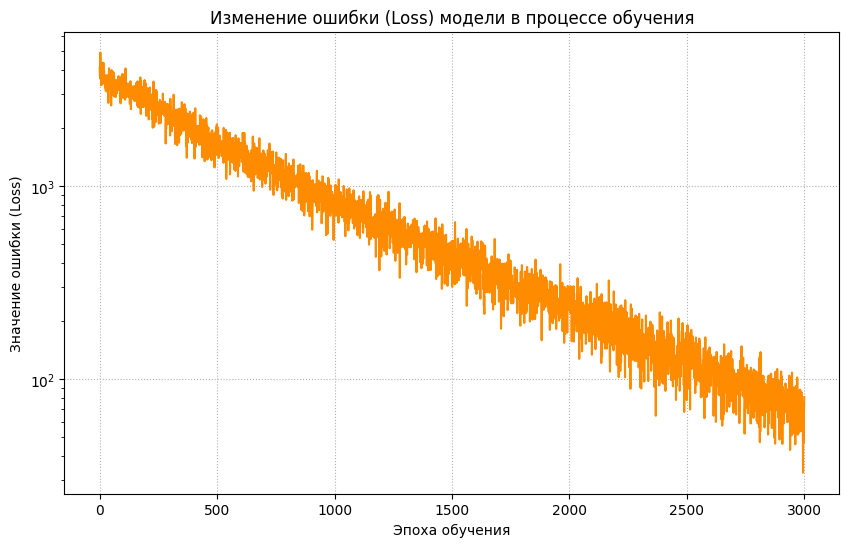

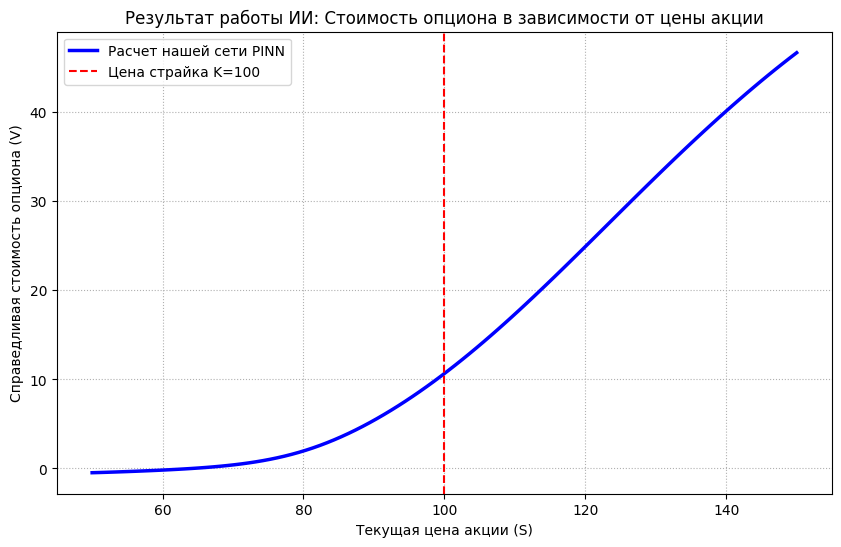

In [ ]:
# 4. Код оптимизатора PINN

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Включаем фиксированные случайные числа, чтобы результаты всегда были одинаковыми
torch.manual_seed(42)
np.random.seed(42)

# 1. НАСТРОЙКА ФИНАНСОВЫХ ПАРАМЕТРОВ РЫНКА
R = 0.05       # Безрисковая ставка в банке (5%)
SIGMA = 0.25   # Волатильность акции (рынок штормит на 25%)
K = 100        # Страйк-цена опциона (цена покупки по контракту = 100)
T = 1          # Общий срок действия контракта (1 год)

# 2. АРХИТЕКТУРА НЕЙРОСЕТИ PINN
class OptionPINN(nn.Module):
    def __init__(self):
        super(OptionPINN, self).__init__()
        # Создаем полносвязную структуру слоев
        self.net = nn.Sequential(
            nn.Linear(2, 40),  # Вход: Цена акции (S) и Время (t)
            nn.Tanh(),         # Функция активации для гладкости графиков
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1)   # Выход: Цена опциона (V)
        )

    def forward(self, S, t):
        # Склеиваем S и t в один вектор для подачи в сеть
        x = torch.cat([S, t], dim=1)
        return self.net(x)

# 3. ВЫЧИСЛЕНИЕ СЛОЖНОЙ ФУНКЦИИ ПОТЕРЬ (LOSS)
def compute_loss(model, S_data, t_data, V_data, S_pde, t_pde):
    mse = nn.MSELoss() # Стандартная среднеквадратичная ошибка

    # 3.1. Расчет Loss_data (Ошибка по точкам данных)
    V_pred_data = model(S_data, t_data)
    loss_data = mse(V_pred_data, V_data)

    # 3.2. Расчет Loss_PDE (Проверка уравнения Блэка-Шоулза)
    # Приказываем PyTorch следить за градиентами, чтобы взять производные
    S_pde.requires_grad_(True)
    t_pde.requires_grad_(True)

    V_pde = model(S_pde, t_pde)

    # Берем первую производную по времени: dV/dt
    dV_dt = torch.autograd.grad(V_pde, t_pde, torch.ones_like(V_pde), create_graph=True)[0]

    # Берем первую производную по цене акции: dV/dS
    dV_dS = torch.autograd.grad(V_pde, S_pde, torch.ones_like(V_pde), create_graph=True)[0]

    # Берем вторую производную по цене акции: d2V/dS2
    d2V_dS2 = torch.autograd.grad(dV_dS, S_pde, torch.ones_like(dV_dS), create_graph=True)[0]

    # Собираем уравнение Блэка-Шоулза. В идеале pde_residual должен быть равен 0
    pde_residual = dV_dt + 0.5 * (SIGMA**2) * (S_pde**2) * d2V_dS2 + R * S_pde * dV_dS - R * V_pde
    loss_pde = mse(pde_residual, torch.zeros_like(pde_residual))

    # 3.3. Расчет Loss_BC (Проверка логики финального дня)
    # Генерируем случайные цены акций для симуляции дня экспирации (t = T)
    S_bound = torch.rand(200, 1) * 200
    t_bound = torch.ones_like(S_bound) * T # Время строго равно концу срока (1)

    # Правильный ответ в финальный день по экономике: max(S - K, 0)
    V_bound_target = torch.clamp(S_bound - K, min=0.0)
    V_bound_pred = model(S_bound, t_bound)
    loss_bc = mse(V_bound_pred, V_bound_target)

    # Складываем все ошибки вместе
    return loss_data + loss_pde + 2.0 * loss_bc

# 4. ПОДГОТОВКА ИСХОДНЫХ ДАННЫХ ДЛЯ ОБУЧЕНИЯ
N_samples = 200
# Генерируем случайные цены акций от 40 до 160 рублей
S_train = torch.rand(N_samples, 1) * 120 + 40
# Генерируем случайное время от 0 до 1 года
t_train = torch.rand(N_samples, 1) * T
# Считаем для них базовые ориентиры цены
V_train = torch.clamp(S_train - K * np.exp(-R * (T - t_train)), min=0.0)

# Создаем большую сетку точек (1000 штук) для постоянной проверки уравнения Блэка-Шоулза
S_pde = torch.rand(1000, 1) * 200.0
t_pde = torch.rand(1000, 1) * T

# 5. ЗАПУСК ПРОЦЕССА ОБУЧЕНИЯ ИИ
model = OptionPINN()
# Оптимизатор Adam — наш инструмент настройки весов нейросети
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Список для сохранения истории ошибки на каждой эпохе (для графика обучения)
loss_history = []

print("Начинаем процесс оптимизации нашей финансовой PINN")
for epoch in range(3001):
    optimizer.zero_grad() # Обнуляем старые ошибки

    # Считаем общую ошибку с учетом законов экономики
    loss = compute_loss(model, S_train, t_train, V_train, S_pde, t_pde)

    loss.backward() # Прогоняем ошибку обратно по сети
    optimizer.step() # Корректируем веса нейронов

    # Сохраняем текущее значение ошибки в историю
    loss_history.append(loss.item())

    # Каждые 500 шагов показываем прогресс
    if epoch % 500 == 0:
        print(f"Шаг обучения: {epoch:4d} | Текущая ошибка (Loss): {loss.item():.6f}")

print("Обучение нейросети успешно завершено!")

# 6. ПОСТРОЕНИЕ ИТОГОВОГО ГРАФИКА РЕЗУЛЬТАТОВ
# Проверим, как сеть определяет цены опционов СЕЙЧАС (при t=0) для акций от 50 до 150 руб.
S_test = torch.linspace(50, 150, 100).view(-1, 1)
t_test = torch.zeros_like(S_test)

with torch.no_grad(): # Градиенты больше не нужны, мы просто тестируем
    V_pred = model(S_test, t_test)

# 7. ГРАФИК ИЗМЕНЕНИЯ ОШИБКИ МОДЕЛИ В ПРОЦЕССЕ ОБУЧЕНИЯ, А ТАКЖЕ ГРАФИК РЕЗУЛЬТАТОВ РАБОТЫ ИИ
plt.figure(figsize=(10, 6))
plt.plot(loss_history, color='darkorange', linewidth=1.5)
plt.title('Изменение ошибки (Loss) модели в процессе обучения')
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение ошибки (Loss)')
plt.yscale('log') 
plt.grid(True, linestyle=':')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(S_test.numpy(), V_pred.numpy(), label='Расчет нашей сети PINN', color='blue', linewidth=2.5)
plt.axvline(x=K, color='red', linestyle='--', label=f'Цена страйка K={K}')
plt.title('Результат работы ИИ: Стоимость опциона в зависимости от цены акции')
plt.xlabel('Текущая цена акции (S)')
plt.ylabel('Справедливая стоимость опциона (V)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()